In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = Path('ecommerce_sales_raw (1).csv')
if not DATA_PATH.exists():
    DATA_PATH = Path(r'D:\Cpu project2\ecommerce_sales_raw (1).csv')

if not DATA_PATH.exists():
    raise FileNotFoundError('Update DATA_PATH to the location of ecommerce_sales_raw (1).csv')

df = pd.read_csv(DATA_PATH)
df.head()


,date,day_of_week,product_category,price,discount_pct,is_holiday_season,units_sold
0,2025-11-01,Saturday,Electronics,1143.00,2.2,0,19
1,2025-11-01,Saturday,Toys,239.67,3.4,0,26
2,2025-11-01,Saturday,Electronics,1151.24,1.9,0,12
3,2025-11-01,Saturday,Toys,247.99,3.6,0,14
4,2025-11-01,Saturday,Home,618.57,0.1,0,20


In [4]:
df.shape

(1459, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               1459 non-null   str    
 1   day_of_week        1459 non-null   str    
 2   product_category   1459 non-null   str    
 3   price              1459 non-null   float64
 4   discount_pct       1459 non-null   float64
 5   is_holiday_season  1459 non-null   int64  
 6   units_sold         1459 non-null   int64  
dtypes: float64(2), int64(2), str(3)
memory usage: 79.9 KB


In [6]:
df.describe()

,price,discount_pct,is_holiday_season,units_sold
count,1459.000000,1459.000000,1459.000000,1459.000000
mean,473.257032,12.138725,0.346813,24.989034
std,347.060173,13.301144,0.476119,15.147103
min,120.010000,0.000000,0.000000,0.000000
25%,209.335000,3.000000,0.000000,15.000000
50%,341.850000,5.800000,0.000000,20.000000
75%,604.890000,23.000000,1.000000,29.000000
max,1259.660000,44.900000,1.000000,93.000000


In [7]:
df.isnull().sum()

date                 0
day_of_week          0
product_category     0
price                0
discount_pct         0
is_holiday_season    0
units_sold           0
dtype: int64

In [8]:
df.head(10)

,date,day_of_week,product_category,price,discount_pct,is_holiday_season,units_sold
0,2025-11-01,Saturday,Electronics,1143.00,2.2,0,19
1,2025-11-01,Saturday,Toys,239.67,3.4,0,26
2,2025-11-01,Saturday,Electronics,1151.24,1.9,0,12
3,2025-11-01,Saturday,Toys,247.99,3.6,0,14
4,2025-11-01,Saturday,Home,618.57,0.1,0,20
5,2025-11-01,Saturday,Home,586.67,1.7,0,10
6,2025-11-01,Saturday,Home,576.13,3.0,0,15
7,2025-11-01,Saturday,Home,618.43,5.8,0,21
8,2025-11-01,Saturday,Toys,240.62,7.4,0,21
9,2025-11-01,Saturday,Toys,259.64,2.9,0,19


In [9]:
df.tail(10)

,date,day_of_week,product_category,price,discount_pct,is_holiday_season,units_sold
1449,2026-01-09,Friday,Toys,163.79,40.1,1,58
1450,2026-01-09,Friday,Beauty,136.87,40.9,1,43
1451,2026-01-09,Friday,Electronics,1012.76,34.4,1,29
1452,2026-01-09,Friday,Fashion,238.14,44.1,1,46
1453,2026-01-09,Friday,Fashion,239.36,23.0,1,49
1454,2026-01-09,Friday,Fashion,276.29,24.2,1,38
1455,2026-01-09,Friday,Fashion,291.00,21.0,1,51
1456,2026-01-09,Friday,Electronics,957.32,35.8,1,38
1457,2026-01-09,Friday,Beauty,124.04,20.2,1,51
1458,2026-01-09,Friday,Electronics,932.02,34.8,1,40


In [10]:
print("Day of Week:")
print(df['day_of_week'].unique())

print("\nProduct Categories:")
print(df['product_category'].unique())

print("\nHoliday Season:")
print(df['is_holiday_season'].unique())

Day of Week:
<StringArray>
['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 7, dtype: str

Product Categories:
<StringArray>
['Electronics', 'Toys', 'Home', 'Fashion', 'Beauty']
Length: 5, dtype: str

Holiday Season:
[0 1]


In [11]:
df['date'] = pd.to_datetime(df['date'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               1459 non-null   datetime64[us]
 1   day_of_week        1459 non-null   str           
 2   product_category   1459 non-null   str           
 3   price              1459 non-null   float64       
 4   discount_pct       1459 non-null   float64       
 5   is_holiday_season  1459 non-null   int64         
 6   units_sold         1459 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 79.9 KB


In [12]:
print("Start Date:", df['date'].min())
print("End Date:", df['date'].max())
print("Number of Days:", df['date'].nunique())

Start Date: 2025-11-01 00:00:00
End Date: 2026-01-09 00:00:00
Number of Days: 70


In [13]:
df = df.sort_values('date').reset_index(drop=True)

df.head()

,date,day_of_week,product_category,price,discount_pct,is_holiday_season,units_sold
0,2025-11-01,Saturday,Electronics,1143.00,2.2,0,19
1,2025-11-01,Saturday,Fashion,360.22,3.4,0,22
2,2025-11-01,Saturday,Electronics,1243.33,1.2,0,17
3,2025-11-01,Saturday,Home,583.16,8.0,0,15
4,2025-11-01,Saturday,Toys,248.21,4.7,0,11


In [14]:
df['date'].duplicated().sum()

np.int64(1389)

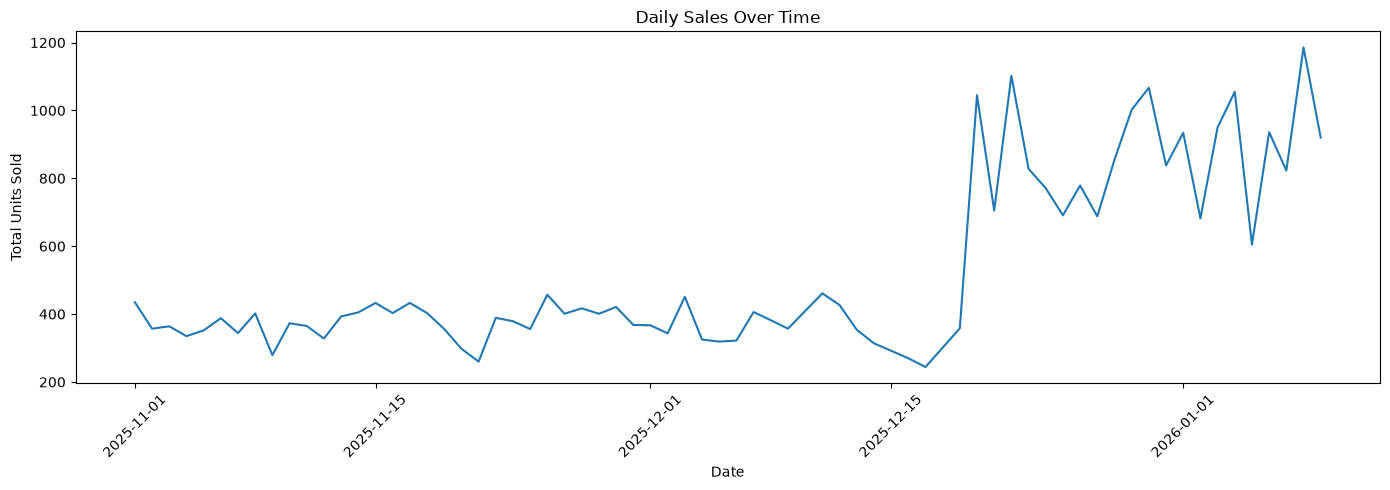

In [15]:
daily_sales = df.groupby('date')['units_sold'].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_sales.index, daily_sales.values)
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.title('Daily Sales Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
df.groupby('is_holiday_season')['units_sold'].agg(
    ['count', 'mean', 'std', 'min', 'max']
)

,count,mean,std,min,max
is_holiday_season,,,,,
0,953,17.347324,4.935725,0,31
1,506,39.381423,17.283850,0,93


In [17]:
df.groupby('is_holiday_season')[['price', 'discount_pct', 'units_sold']].mean()

,price,discount_pct,units_sold
is_holiday_season,,,
0,517.363620,4.154565,17.347324
1,390.186719,27.176087,39.381423


In [19]:
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['day_of_week_num'] = df['date'].dt.dayofweek
df.head()

,date,day_of_week,product_category,price,discount_pct,is_holiday_season,units_sold,month,day,week,day_of_week_num
0,2025-11-01,Saturday,Electronics,1143.00,2.2,0,19,11,1,44,5
1,2025-11-01,Saturday,Fashion,360.22,3.4,0,22,11,1,44,5
2,2025-11-01,Saturday,Electronics,1243.33,1.2,0,17,11,1,44,5
3,2025-11-01,Saturday,Home,583.16,8.0,0,15,11,1,44,5
4,2025-11-01,Saturday,Toys,248.21,4.7,0,11,11,1,44,5


In [20]:
numeric_cols = [
    'price',
    'discount_pct',
    'is_holiday_season',
    'units_sold',
    'month',
    'day',
    'week',
    'day_of_week_num'
]

df[numeric_cols].corr()['units_sold'].sort_values(ascending=False)

units_sold           1.000000
discount_pct         0.770125
is_holiday_season    0.692598
day                  0.110861
day_of_week_num     -0.019887
price               -0.169391
month               -0.439141
week                -0.537988
Name: units_sold, dtype: float64

In [36]:
features = [
    'price',
    'discount_pct',
    'is_holiday_season'
]

X = df[features]
y = df['units_sold']

In [22]:
start_date = df['date'].min()

print("Start Date:", start_date)

Start Date: 2025-11-01 00:00:00


In [23]:
train_end_date = start_date + pd.Timedelta(days=20)

print("Training Period Ends:", train_end_date)

Training Period Ends: 2025-11-21 00:00:00


In [24]:
train_df = df[df['date'] <= train_end_date].copy()

test_df = df[df['date'] > train_end_date].copy()

print("Training Data:", train_df.shape)
print("Testing Data:", test_df.shape)

Training Data: (442, 11)
Testing Data: (1017, 11)


In [25]:
print("Training Start:", train_df['date'].min())
print("Training End:", train_df['date'].max())

print("\nTesting Start:", test_df['date'].min())
print("Testing End:", test_df['date'].max())

Training Start: 2025-11-01 00:00:00
Training End: 2025-11-21 00:00:00

Testing Start: 2025-11-22 00:00:00
Testing End: 2026-01-09 00:00:00


In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    train_df[features],
    train_df['units_sold']
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0. ,-0.02, 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['price','discount_pct','is_holiday_season']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,17.37
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [27]:
test_df['predicted_units'] = model.predict(
    test_df[features]
)

test_df.head(10)

,date,day_of_week,product_category,price,discount_pct,is_holiday_season,units_sold,month,day,week,day_of_week_num,predicted_units
442,2025-11-22,Saturday,Home,587.27,4.6,0,14,11,22,47,5,17.442628
443,2025-11-22,Saturday,Toys,246.99,7.8,0,23,11,22,47,5,17.305330
444,2025-11-22,Saturday,Fashion,342.67,2.3,0,6,11,22,47,5,17.417728
445,2025-11-22,Saturday,Electronics,1181.56,3.5,0,17,11,22,47,5,17.610413
446,2025-11-22,Saturday,Fashion,361.48,2.2,0,23,11,22,47,5,17.424084
447,2025-11-22,Saturday,Fashion,354.83,0.4,0,11,11,22,47,5,17.451279
448,2025-11-22,Saturday,Fashion,334.28,7.2,0,13,11,22,47,5,17.337007
449,2025-11-22,Saturday,Electronics,1221.74,1.1,0,22,11,22,47,5,17.659062
450,2025-11-22,Saturday,Toys,261.95,1.3,0,12,11,22,47,5,17.413377
451,2025-11-22,Saturday,Beauty,196.34,2.8,0,26,11,22,47,5,17.372739


In [28]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    test_df['units_sold'],
    test_df['predicted_units']
)

print("Overall MAE:", mae)

Overall MAE: 13.726884795891849


In [29]:
test_df['test_week'] = (
    (test_df['date'] - train_end_date).dt.days // 7
) + 1

In [30]:
weekly_mae = (
    test_df.groupby('test_week')
    .apply(
        lambda group: mean_absolute_error(
            group['units_sold'],
            group['predicted_units']
        )
    )
    .reset_index(name='MAE')
)

weekly_mae

,test_week,MAE
0,1,4.295823
1,2,4.089309
2,3,3.684990
3,4,4.239274
4,5,23.369421
5,6,28.144102
6,7,28.114693
7,8,25.683597


In [31]:
print("Weekly MAE")
print(weekly_mae.to_string(index=False))

Weekly MAE
 test_week       MAE
         1  4.295823
         2  4.089309
         3  3.684990
         4  4.239274
         5 23.369421
         6 28.144102
         7 28.114693
         8 25.683597


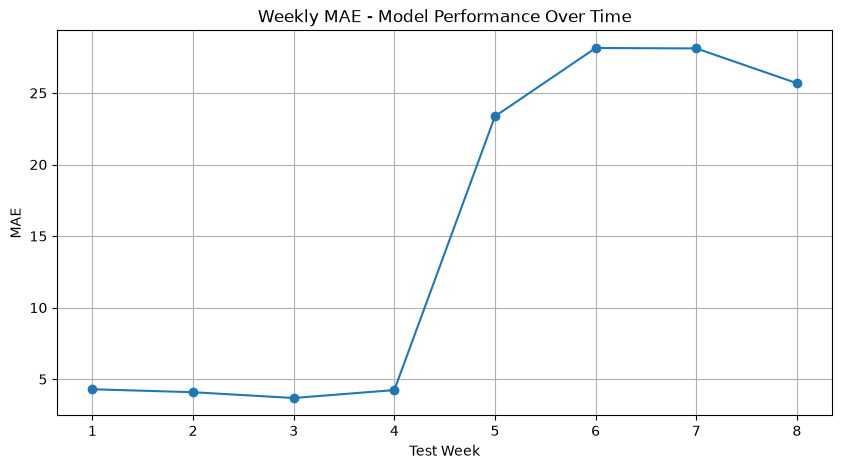

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    weekly_mae['test_week'],
    weekly_mae['MAE'],
    marker='o'
)

plt.xlabel('Test Week')
plt.ylabel('MAE')
plt.title('Weekly MAE - Model Performance Over Time')
plt.xticks(weekly_mae['test_week'])
plt.grid(True)

plt.show()

## Drift monitoring and incident decision

The model was trained only on the first three weeks. The following checks quantify the point at which its prediction error becomes operationally unsafe.

In [33]:
# Reference performance is the stable part of the test period (weeks 1-4).
reference_mae = weekly_mae.loc[weekly_mae['test_week'] <= 4, 'MAE'].mean()
alert_threshold = 2 * reference_mae

weekly_mae['MAE_vs_reference'] = weekly_mae['MAE'] / reference_mae
weekly_mae['alert'] = weekly_mae['MAE'] > alert_threshold

first_alert_week = weekly_mae.loc[weekly_mae['alert'], 'test_week'].min()
first_alert_date = test_df.loc[test_df['test_week'] == first_alert_week, 'date'].min()

print(f'Reference MAE (weeks 1-4): {reference_mae:.2f}')
print(f'Alert threshold (2x reference): {alert_threshold:.2f}')
print(f'First alert: week {first_alert_week}, starting {first_alert_date.date()}')
weekly_mae

Reference MAE (weeks 1-4): 4.08
Alert threshold (2x reference): 8.15
First alert: week 5, starting 2025-12-19


,test_week,MAE,MAE_vs_reference,alert
0,1,4.295823,1.053582,False
1,2,4.089309,1.002933,False
2,3,3.684990,0.903771,False
3,4,4.239274,1.039713,False
4,5,23.369421,5.731523,True
5,6,28.144102,6.902549,True
6,7,28.114693,6.895336,True
7,8,25.683597,6.299092,True


### Diagnosis: data drift, not a code bug

The error stays close to 4 units in test weeks 1-4, then jumps above 23 units in week 5. That jump coincides with the holiday regime. The model code runs correctly; the relationship between inputs and sales has changed.

Importantly, the first three training weeks contain no holiday observations. Therefore, `is_holiday_season` has no variation in training and a linear model cannot learn its effect. Adding that column alone does not solve the incident.

In [34]:
# Evidence for the root cause: the training set never saw a holiday example.
holiday_coverage = pd.DataFrame({
    'train_rows': train_df.groupby('is_holiday_season').size(),
    'test_rows': test_df.groupby('is_holiday_season').size(),
    'test_MAE': test_df.groupby('is_holiday_season').apply(
        lambda g: mean_absolute_error(g['units_sold'], g['predicted_units'])
    )
}).fillna(0)

print('Holiday period starts:', df.loc[df['is_holiday_season'] == 1, 'date'].min().date())
holiday_coverage

Holiday period starts: 2025-12-15


,train_rows,test_rows,test_MAE
is_holiday_season,,,
0,442.0,511,4.064707
1,0.0,506,23.484538


## Final operational response

1. **Contain immediately:** when the seven-day MAE crosses twice the normal level (week 5), stop using the legacy forecast for automated purchasing or staffing decisions. Use a reviewed seasonal fallback forecast and mark decisions as manual until validation passes.
2. **Collect the missing regime:** retain actual sales, product category, price, discount, stock availability, campaigns, and holiday/event labels daily. The current failure occurred because the old data has no holiday examples.
3. **Retrain safely:** after enough labelled holiday days are available, train a new version with product category encoding and calendar/event features. Validate it with time-ordered folds (never a random split) and compare it with the legacy model on the latest seven days.
4. **Deploy only with a gate:** promote the new version only if its MAE is below the agreed business threshold and materially lower than the legacy model. Otherwise keep the fallback and investigate new drivers.
5. **Prevent recurrence:** monitor daily and weekly MAE by season and product category; alert at 2x the stable reference MAE, log the incident, and schedule retraining whenever a new event regime appears.

This is not a reason to retrain blindly on the original three weeks: that would reproduce the same blind spot. The priority is a safe fallback, labelled seasonal data, then a time-validated retrain.

In [35]:
# Reusable production-style monitoring rule.
def should_pause_legacy_model(current_7day_mae, reference_mae, multiplier=2.0):
    """Return True when prediction error exceeds the agreed safety threshold."""
    return current_7day_mae > multiplier * reference_mae

print('Pause legacy model:', should_pause_legacy_model(
    weekly_mae.loc[weekly_mae['test_week'] == first_alert_week, 'MAE'].iloc[0],
    reference_mae
))

Pause legacy model: True
